# Gen1 final unfolding (χ²/ndof = 34.5/12 for `tki-del_Tp`)

Rebuilds the Wiener-SVD unfold that produced the PRL/thesis generator-comparison
χ² of **34.5/12** for `tki-del_Tp`, for all CORE selected variables **including
`integrated`**, and writes a lean results file (counts + response + unfold).

## Provenance (original May DFs are gone from pnfs)

| Ingredient | Source |
|---|---|
| Measurement, MC hist counts, event arrays for response | `Gen1_unfold_cache_efielddet_noneutron.pkl` |
| Exact input covariance used in that unfold | Recovered via `CovRotation⁻¹ @ SystUnfoldCov @ CovRotation⁻ᵀ` |
| Contemporaneous dumped frac cov (close, not identical) | `frac_cov_dict_noneutrons.pkl` |
| Integrated syst (not in Gen1 cache) | mixed `category_syst_summary.npz` → `total_xsec` (from `systematics-genie-mixed-summary.ipynb`) |

Recomputed χ² from the cached unfold: **34.528 / 12**.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
import json
from pathlib import Path
import pickle

import numpy as np

sys.path.append("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")

from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.final_selected_evt_vars import CORE_SELECTED_EVT_VARIABLE_CONFIGS
from analysis_village.numucc_1p0pi.utils import (
    get_response_matrix,
    cov_from_fraccov,
    fraccov_from_cov,
    plot_unfolded_result,
)
from analysis_village.unfolding.wienersvd import WienerSVD


In [3]:
DATA_RESULTS = Path("/exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS")
GEN1_CACHE_PATH = DATA_RESULTS / "Gen1_unfold_cache_efielddet_noneutron.pkl"
FRAC_COV_NONEUTRONS_PATH = DATA_RESULTS / "frac_cov_dict_noneutrons.pkl"
# Mixed GENIE (sel_mup CCQE+Ar23p + unfolding-era other modes) + unfolding-era
# non-GENIE categories; written by systematics-genie-mixed-summary.ipynb.
CATEGORY_SUMMARY_NPZ = Path(
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
    "/genie_syst_mixed_sel_mup_CCQE_Ar23p_summary"
    "/CategorySummary/category_syst_summary.npz"
)

OUT_DIR = DATA_RESULTS / "gen1_final_unfold"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PKL = OUT_DIR / "unfolding_ingredients_and_results.pkl"
OUT_NPZ = OUT_DIR / "unfolding_ingredients_and_results.npz"

C_TYPE = 2
NORM_TYPE = 0.0

print("Gen1 cache :", GEN1_CACHE_PATH)
print("frac cov   :", FRAC_COV_NONEUTRONS_PATH)
print("output     :", OUT_PKL)


Gen1 cache : /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/Gen1_unfold_cache_efielddet_noneutron.pkl
frac cov   : /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/frac_cov_dict_noneutrons.pkl
output     : /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/gen1_final_unfold/unfolding_ingredients_and_results.pkl


In [4]:
with open(GEN1_CACHE_PATH, "rb") as f:
    gen1_cache = pickle.load(f)

with open(FRAC_COV_NONEUTRONS_PATH, "rb") as f:
    frac_cov_noneutrons = pickle.load(f)

category_summary = np.load(CATEGORY_SUMMARY_NPZ, allow_pickle=True)

print("Gen1 vars:", sorted(gen1_cache.keys()))
print("frac_cov_noneutrons vars:", sorted(frac_cov_noneutrons.keys()))


Gen1 vars: ['muon-dir_z', 'muon-p', 'proton-dir_z', 'proton-p', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_alpha', 'tki-del_p', 'tki-del_phi']
frac_cov_noneutrons vars: ['muon-dir_z', 'muon-p', 'proton-dir_z', 'proton-p', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_alpha', 'tki-del_p', 'tki-del_phi']


In [5]:
def xsec_unit_from_entry(entry):
    model = np.asarray(entry["model"], dtype=float)
    nevts_allmc = np.asarray(entry["ret_signal_hists"]["nevts_allmc"], dtype=float)
    return float(np.mean(model / nevts_allmc))


def recover_input_covariance(unfold, xsec_unit):
    """Recover pre-Wiener Covariance (xsec units) from CovRotation / SystUnfoldCov."""
    CR = np.asarray(unfold["CovRotation"], dtype=float)
    Syst = np.asarray(unfold["SystUnfoldCov"], dtype=float)
    invCR = np.linalg.inv(CR)
    return invCR @ Syst @ invCR.T


def build_response(sig, bins):
    bins = np.asarray(bins, dtype=float)
    if len(bins) == 2:
        reco_vs_true = np.array([[float(np.sum(sig["nevts_sel_truth"]))]], dtype=float)
    else:
        reco_vs_true, _, _ = np.histogram2d(
            np.asarray(sig["var_sel_truth"], dtype=float),
            np.asarray(sig["var_sel_reco"], dtype=float),
            weights=np.asarray(sig["wgt_sel_truth"], dtype=float),
            bins=bins,
        )
    nevts_allmc = np.asarray(sig["nevts_allmc"], dtype=float)
    nevts_sel_truth = np.asarray(sig["nevts_sel_truth"], dtype=float)
    eff = nevts_sel_truth / nevts_allmc
    response = get_response_matrix(reco_vs_true, eff)
    return reco_vs_true, eff, response


def chi2_vs_model(unfold, model, bins):
    bins = np.asarray(bins, dtype=float)
    bw = np.diff(bins) if len(bins) > 2 else np.array([1.0])
    U = np.asarray(unfold["unfold"], dtype=float)
    As = np.asarray(unfold["AddSmear"], dtype=float)
    Uc = np.asarray(unfold["UnfoldCov"], dtype=float)
    cov_pw = Uc * np.outer(1.0 / bw, 1.0 / bw)
    U_pw = U / bw
    M_pw = (As @ np.asarray(model, dtype=float)) / bw
    mask = (U_pw > 0) & (M_pw > 0)
    diff = U_pw[mask] - M_pw[mask]
    chi2 = float(diff @ np.linalg.solve(cov_pw[np.ix_(mask, mask)], diff))
    return chi2, int(np.sum(mask))


# reference xsec_unit from tki-del_Tp
XSEC_UNIT = xsec_unit_from_entry(gen1_cache["tki-del_Tp"])
print(f"xsec_unit = {XSEC_UNIT:.6e}")


xsec_unit = 6.657611e-43


## Unfold all CORE variables present in the Gen1 cache

For each variable: rebuild the response from cached event arrays, recover the
exact input covariance used in the original Wiener-SVD, re-run the unfold, and
package lean ingredient counts (no full DFs).


In [6]:
vc_by_name = {vc.var_save_name: vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS}
results = {
    "meta": {
        "description": (
            "Gen1 final unfold rebuilt from Gen1_unfold_cache_efielddet_noneutron.pkl; "
            "exact Covariance recovered via CovRotation. Reference χ²(tki-del_Tp)=34.5/12."
        ),
        "gen1_cache_path": str(GEN1_CACHE_PATH),
        "frac_cov_noneutrons_path": str(FRAC_COV_NONEUTRONS_PATH),
        "category_summary_path": str(CATEGORY_SUMMARY_NPZ),
        "xsec_unit": float(XSEC_UNIT),
        "C_type": C_TYPE,
        "Norm_type": NORM_TYPE,
        "note_data_bkg": (
            "nevts_data_minus_bkg = measured/xsec_unit (bkg-subtracted data used in unfold). "
            "nevts_mc_bkgd = nevts_allsel_reco - nevts_sel_reco (MC estimate of selected bkg)."
        ),
    },
    "variables": {},
}

chi2_summary = {}

for vsn, entry in sorted(gen1_cache.items()):
    vc = entry.get("var_config") or vc_by_name[vsn]
    bins = np.asarray(vc.bins, dtype=float)
    sig = entry["ret_signal_hists"]
    measured = np.asarray(entry["measured"], dtype=float)
    model = np.asarray(entry["model"], dtype=float)
    assert np.isclose(xsec_unit_from_entry(entry), XSEC_UNIT, rtol=1e-9)

    reco_vs_true, eff, response = build_response(sig, bins)
    Cov_in = recover_input_covariance(entry["unfold"], XSEC_UNIT)
    nevts_sel_reco = np.asarray(sig["nevts_sel_reco"], dtype=float)
    frac_cov_exact = fraccov_from_cov(Cov_in / XSEC_UNIT**2, nevts_sel_reco)

    unfold = WienerSVD(
        response, model, measured, Cov_in, C_TYPE, NORM_TYPE, stat_scaling=XSEC_UNIT
    )
    chi2, ndof = chi2_vs_model(unfold, model, bins)
    chi2_summary[vsn] = (chi2, ndof)

    nevts_allmc = np.asarray(sig["nevts_allmc"], dtype=float)
    nevts_sel_truth = np.asarray(sig["nevts_sel_truth"], dtype=float)
    nevts_allsel_reco = np.asarray(sig["nevts_allsel_reco"], dtype=float)
    nevts_data_minus_bkg = measured / XSEC_UNIT
    nevts_mc_bkgd = nevts_allsel_reco - nevts_sel_reco

    results["variables"][vsn] = {
        "bins": bins,
        "bin_centers": np.asarray(vc.bin_centers, dtype=float),
        "ingredients": {
            "nevts_data_minus_bkg": nevts_data_minus_bkg,
            "nevts_mc_bkgd": nevts_mc_bkgd,
            "nevts_data_approx": nevts_data_minus_bkg + nevts_mc_bkgd,
            "nevts_allmc": nevts_allmc,
            "nevts_sel_reco": nevts_sel_reco,
            "nevts_sel_truth": nevts_sel_truth,
            "nevts_allsel_reco": nevts_allsel_reco,
            "reco_vs_true": np.asarray(reco_vs_true, dtype=float),
            "efficiency": np.asarray(eff, dtype=float),
            "response": np.asarray(response, dtype=float),
            "frac_cov_exact": np.asarray(frac_cov_exact, dtype=float),
            "frac_cov_noneutrons_dump": (
                np.asarray(frac_cov_noneutrons[vsn], dtype=float)
                if vsn in frac_cov_noneutrons
                else None
            ),
            "Covariance_xsec": np.asarray(Cov_in, dtype=float),
        },
        "results": {
            "measured": measured,
            "model": model,
            "unfold": np.asarray(unfold["unfold"], dtype=float),
            "AddSmear": np.asarray(unfold["AddSmear"], dtype=float),
            "UnfoldCov": np.asarray(unfold["UnfoldCov"], dtype=float),
            "StatUnfoldCov": np.asarray(unfold["StatUnfoldCov"], dtype=float),
            "SystUnfoldCov": np.asarray(unfold["SystUnfoldCov"], dtype=float),
            "stat_err": np.sqrt(np.maximum(np.diag(unfold["StatUnfoldCov"]), 0.0)),
            "syst_err": np.sqrt(np.maximum(np.diag(unfold["SystUnfoldCov"]), 0.0)),
            "total_err": np.sqrt(np.maximum(np.diag(unfold["UnfoldCov"]), 0.0)),
            "chi2_genie": float(chi2),
            "ndof": int(ndof),
        },
        "var_save_name": vsn,
    }
    print(f"{vsn:16s}  χ²/ndof = {chi2:.1f}/{ndof}")

print("\nReference check: tki-del_Tp →", f"{chi2_summary['tki-del_Tp'][0]:.1f}/{chi2_summary['tki-del_Tp'][1]}")
assert abs(chi2_summary["tki-del_Tp"][0] - 34.5) < 0.05, chi2_summary["tki-del_Tp"]


muon-dir_z        χ²/ndof = 49.6/14
muon-p            χ²/ndof = 4.1/12
proton-dir_z      χ²/ndof = 25.3/10
proton-p          χ²/ndof = 13.4/13
tki-del_Tp        χ²/ndof = 34.5/12
tki-del_Tp_x      χ²/ndof = 26.1/13
tki-del_Tp_y      χ²/ndof = 15.8/13
tki-del_alpha     χ²/ndof = 3.2/8
tki-del_p         χ²/ndof = 28.1/12
tki-del_phi       χ²/ndof = 9.1/11

Reference check: tki-del_Tp → 34.5/12


## Add `integrated` (not stored in Gen1 cache)

Built by summing any multi-bin Gen1 variable (same selection), with fractional
covariance from mixed `category_syst_summary.npz` → `total_xsec`
(GENIE from `systematics-genie-mixed-summary.ipynb`; other categories unfolding-era).


In [7]:
ref = results["variables"]["tki-del_Tp"]
ing = ref["ingredients"]
vc_int = VariableConfig.all_events()
bins_int = np.asarray(vc_int.bins, dtype=float)

# Single-bin sums from the reference variable
def _sum(a):
    return np.asarray([float(np.sum(a))], dtype=float)

nevts_allmc_i = _sum(ing["nevts_allmc"])
nevts_sel_reco_i = _sum(ing["nevts_sel_reco"])
nevts_sel_truth_i = _sum(ing["nevts_sel_truth"])
nevts_allsel_reco_i = _sum(ing["nevts_allsel_reco"])
nevts_data_minus_bkg_i = _sum(ing["nevts_data_minus_bkg"])
nevts_mc_bkgd_i = _sum(ing["nevts_mc_bkgd"])

eff_i = nevts_sel_truth_i / nevts_allmc_i
reco_vs_true_i = np.array([[float(nevts_sel_truth_i[0])]], dtype=float)
response_i = get_response_matrix(reco_vs_true_i, eff_i)

measured_i = nevts_data_minus_bkg_i * XSEC_UNIT
model_i = nevts_allmc_i * XSEC_UNIT

cat_int = category_summary["integrated"].item()
frac_cov_i = np.asarray(cat_int["total_xsec"]["cov_frac"], dtype=float)
Cov_i = cov_from_fraccov(frac_cov_i, nevts_sel_reco_i) * XSEC_UNIT**2

unfold_i = WienerSVD(
    response_i, model_i, measured_i, Cov_i, C_TYPE, NORM_TYPE, stat_scaling=XSEC_UNIT
)
chi2_i, ndof_i = chi2_vs_model(unfold_i, model_i, bins_int)
chi2_summary["integrated"] = (chi2_i, ndof_i)
print(f"integrated       χ²/ndof = {chi2_i:.1f}/{ndof_i}")

results["variables"]["integrated"] = {
    "bins": bins_int,
    "bin_centers": np.asarray(vc_int.bin_centers, dtype=float),
    "ingredients": {
        "nevts_data_minus_bkg": nevts_data_minus_bkg_i,
        "nevts_mc_bkgd": nevts_mc_bkgd_i,
        "nevts_data_approx": nevts_data_minus_bkg_i + nevts_mc_bkgd_i,
        "nevts_allmc": nevts_allmc_i,
        "nevts_sel_reco": nevts_sel_reco_i,
        "nevts_sel_truth": nevts_sel_truth_i,
        "nevts_allsel_reco": nevts_allsel_reco_i,
        "reco_vs_true": reco_vs_true_i,
        "efficiency": eff_i,
        "response": np.asarray(response_i, dtype=float),
        "frac_cov_exact": frac_cov_i,
        "frac_cov_noneutrons_dump": None,
        "Covariance_xsec": Cov_i,
        "frac_cov_source": "mixed category_syst_summary.npz:total_xsec",
    },
    "results": {
        "measured": measured_i,
        "model": model_i,
        "unfold": np.asarray(unfold_i["unfold"], dtype=float),
        "AddSmear": np.asarray(unfold_i["AddSmear"], dtype=float),
        "UnfoldCov": np.asarray(unfold_i["UnfoldCov"], dtype=float),
        "StatUnfoldCov": np.asarray(unfold_i["StatUnfoldCov"], dtype=float),
        "SystUnfoldCov": np.asarray(unfold_i["SystUnfoldCov"], dtype=float),
        "stat_err": np.sqrt(np.maximum(np.diag(unfold_i["StatUnfoldCov"]), 0.0)),
        "syst_err": np.sqrt(np.maximum(np.diag(unfold_i["SystUnfoldCov"]), 0.0)),
        "total_err": np.sqrt(np.maximum(np.diag(unfold_i["UnfoldCov"]), 0.0)),
        "chi2_genie": float(chi2_i),
        "ndof": int(ndof_i),
    },
    "var_save_name": "integrated",
}


integrated       χ²/ndof = 1.9/1


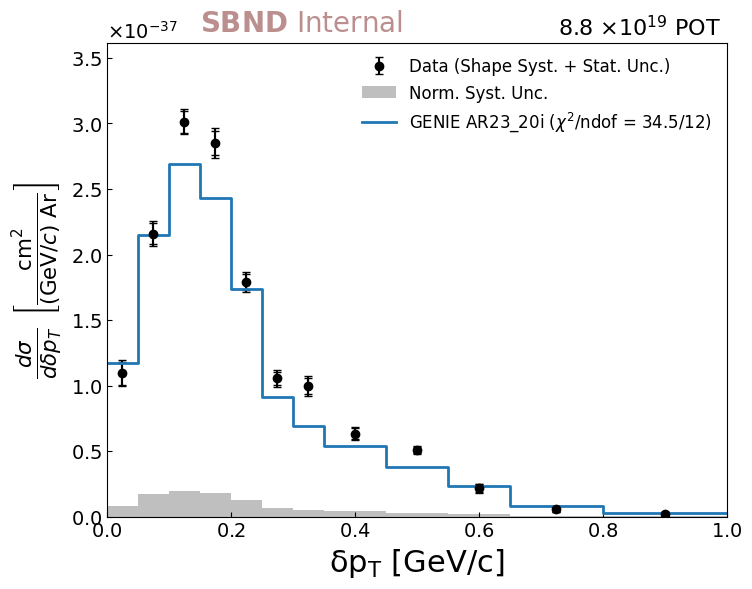

In [8]:
# Quick GENIE-only plot for tki-del_Tp (sanity check of 34.5/12 on the legend)
vc = VariableConfig.tki_del_Tp()
blob = results["variables"]["tki-del_Tp"]
unfold_plot = {
    "unfold": blob["results"]["unfold"],
    "AddSmear": blob["results"]["AddSmear"],
    "UnfoldCov": blob["results"]["UnfoldCov"],
    "StatUnfoldCov": blob["results"]["StatUnfoldCov"],
    "SystUnfoldCov": blob["results"]["SystUnfoldCov"],
}
models = {"GENIE AR23_20i": [blob["results"]["model"], "C0"]}
plot_unfolded_result(
    unfold_plot,
    blob["results"]["measured"],
    models,
    vc,
    xsec_unit=XSEC_UNIT,
    save_fig=False,
    data=True,
)


In [9]:
# Save pickle (nested dict) and a flat npz index for quick loading
with open(OUT_PKL, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

npz_kw = {
    "meta_json": np.array(json.dumps(results["meta"])),
    "variable_names": np.array(sorted(results["variables"].keys())),
}
for vsn, blob in results["variables"].items():
    for section in ("ingredients", "results"):
        for key, val in blob[section].items():
            if val is None:
                continue
            npz_kw[f"{vsn}::{section}::{key}"] = np.asarray(val)
    npz_kw[f"{vsn}::bins"] = blob["bins"]
    npz_kw[f"{vsn}::bin_centers"] = blob["bin_centers"]

np.savez_compressed(OUT_NPZ, **npz_kw)

print("wrote", OUT_PKL)
print("wrote", OUT_NPZ)
print("variables:", sorted(results["variables"].keys()))
print("χ² summary:")
for vsn, (c2, nd) in sorted(chi2_summary.items()):
    print(f"  {vsn:16s}  {c2:.1f}/{nd}")


wrote /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/gen1_final_unfold/unfolding_ingredients_and_results.pkl
wrote /exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS/gen1_final_unfold/unfolding_ingredients_and_results.npz
variables: ['integrated', 'muon-dir_z', 'muon-p', 'proton-dir_z', 'proton-p', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_alpha', 'tki-del_p', 'tki-del_phi']
χ² summary:
  integrated        1.9/1
  muon-dir_z        49.6/14
  muon-p            4.1/12
  proton-dir_z      25.3/10
  proton-p          13.4/13
  tki-del_Tp        34.5/12
  tki-del_Tp_x      26.1/13
  tki-del_Tp_y      15.8/13
  tki-del_alpha     3.2/8
  tki-del_p         28.1/12
  tki-del_phi       9.1/11
